**1. Lagrange Interpolation**


In [12]:
import numpy as np
from scipy.interpolate import lagrange

# Data points
x = np.array([0, 1, 2])
y = np.array([1, 3, 2])

# Compute interpolating polynomial
P = lagrange(x, y)

print("Interpolating polynomial:")
print(P)
print("P(1.5) =", P(1.5))  # Evaluate at x=1.5


Interpolating polynomial:
      2
-1.5 x + 3.5 x + 1
P(1.5) = 2.875


**2. Least Squares Fit**

       3       2
1.667 x - 6.5 x + 5.833 x + 1
[ 1.66666667 -6.5         5.83333333  1.        ]


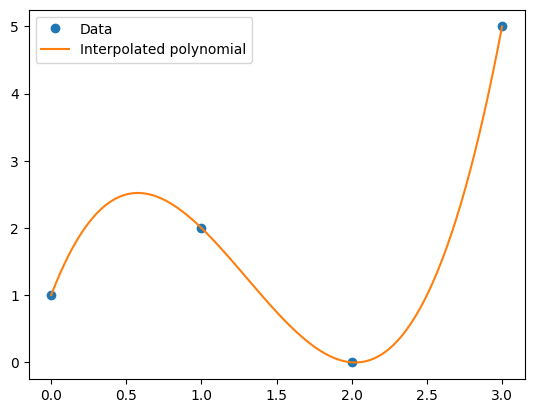

In [13]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0, 1, 2, 3])
y = np.array([1, 2, 0, 5])

# Fit a degree-3 polynomial
coeffs = np.polyfit(x, y, 3)
P = np.poly1d(coeffs)
print(P)
print(coeffs)
# Evaluate on fine grid
x_fit = np.linspace(min(x), max(x), 100)
y_fit = P(x_fit)

plt.plot(x, y, 'o', label='Data')
plt.plot(x_fit, y_fit, '-', label='Interpolated polynomial')
plt.legend()
plt.show()

**3. Newton interpolation**

In [16]:
import sympy as sp
import numpy as np

def divided_differences(x, y):
    x = np.array(x, dtype=float)
    coef = np.array(y, dtype=float)
    n = len(x)
    for j in range(1, n):
        coef[j:n] = (coef[j:n] - coef[j-1]) / (x[j:n] - x[j-1])
    return coef

def newton_symbolic(x_vals, y_vals):
    x = sp.symbols('x')
    n = len(x_vals)
    coef = divided_differences(x_vals, y_vals)
    poly = 0
    term = 1
    for i in range(n):
        poly += coef[i] * term
        term *= (x - x_vals[i])
    return sp.simplify(poly)

# Usage:
x_vals = [1, 2, 4, 3]
y_vals = [1, 4, 2, 5]

P = newton_symbolic(x_vals, y_vals)
print("Newton interpolating polynomial:")
print(P)

Newton interpolating polynomial:
-0.333333333333333*x**3 + 1.0*x**2 + 2.33333333333333*x - 2.0


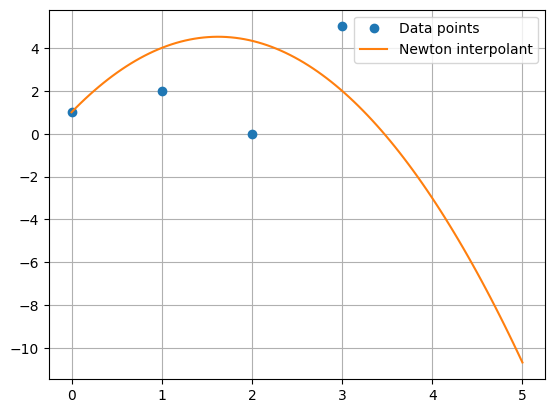

In [18]:
import matplotlib.pyplot as plt

x_vals = np.linspace(0, 5, 100)
y_vals = [newton_poly(a, x, xi) for xi in x_vals]

plt.plot(x, y, 'o', label='Data points')
plt.plot(x_vals, y_vals, '-', label='Newton interpolant')
plt.legend()
plt.grid(True)
plt.show()
